# **Campaign Performance Prediction Model**

This model predicts whether a customer will respond to a marketing campaign.

It helps businesses identify customers who are likely to subscribe, improving
marketing efficiency and reducing unnecessary campaign costs.


## Problem Statement

Marketing campaigns target many customers, but not all of them respond positively.

The goal of this model is to predict:
- Whether a customer will subscribe to a deposit.
- Based on demographic and campaign-related features.

This is a classification problem where:
1 → Customer will subscribe
0 → Customer will not subscribe


## Algorithm Used: Random Forest

Random Forest is an ensemble machine learning algorithm that combines multiple
decision trees to improve prediction accuracy.

Advantages:
- Handles both numerical and categorical data.
- Reduces overfitting.
- Works well on real-world datasets.

The final prediction is made by taking the majority vote from all trees.


In [ ]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

We use the Bank Marketing dataset.
This dataset contains customer information and campaign results.

Target column:
deposit → yes or no


In [ ]:
df = pd.read_csv("bank.csv")
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Information

This step shows:
- Number of rows and columns
- Data types
- Missing values


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


## Data Preprocessing

The dataset contains categorical features such as:
- job
- marital
- education
- contact
- poutcome

Machine learning models require numerical inputs.
So we convert categorical values into numbers using Label Encoding.


In [ ]:
label_encoders = {}

for column in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


## Feature and Target Split

We separate:
- Features (X) → all input columns
- Target (y) → deposit column


In [ ]:
X = df.drop("deposit", axis=1)
y = df["deposit"]


## Train-Test Split

We divide the dataset into:
- 80% training data
- 20% testing data


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 8929
Testing samples: 2233


## Model Training using Random Forest

Random Forest builds multiple decision trees and combines their predictions.
This improves accuracy and reduces overfitting.
shape[0])


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Model Prediction


In [ ]:
y_pred = model.predict(X_test)


## Model Evaluation

We evaluate the model using:
- Accuracy score
- Classification report
- Confusion matrix


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model Accuracy: 0.8334079713390058

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233


Confusion Matrix:
[[952 214]
 [158 909]]


## Save Trained Model

We save the trained model as a .pkl file.
This file will be used in the backend of the dashboard.


In [ ]:
with open("campaign_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as campaign_model.pkl")


Model saved as campaign_model.pkl


## Confusion Matrix

This graph shows the number of correct and incorrect predictions made by the model.
It compares actual values with predicted values to evaluate performance.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


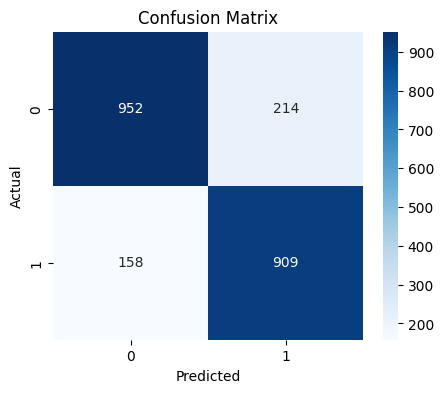

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Feature Importance

This graph shows how much each input feature contributes to the prediction.
Features with higher importance have a greater impact on the model’s decision.


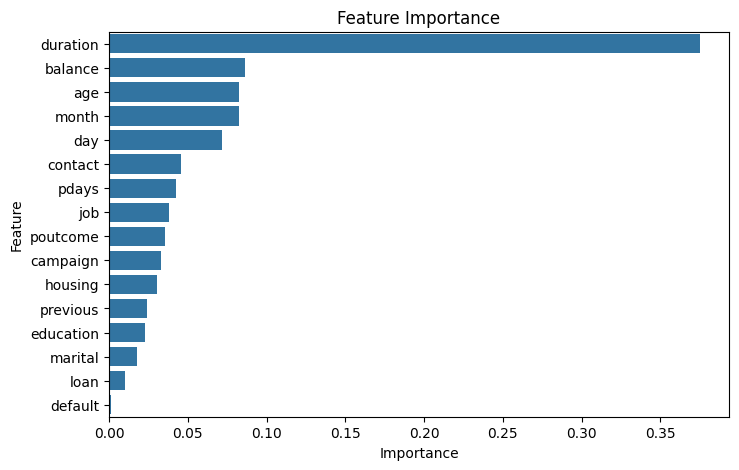

In [ ]:
importances = model.feature_importances_
features = X.columns

# Create DataFrame
feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.title("Feature Importance")
plt.show()
